In [15]:
# =============================================================================
# Data Loading and Integration
# =============================================================================

import numpy as np
import pandas as pd

# Ensure data_dir and output_dir are defined (if not already from Cell 1)
if 'data_dir' not in dir():
    from pathlib import Path
    data_dir = Path("Datasets/RW_Datasets")
    if not data_dir.exists():
        data_dir = Path.cwd().parent / "Datasets" / "RW_Datasets"

# Define output directory
OUTPUT_DIR = Path.cwd().parent / "Results" / "_iteration_0" if Path.cwd().name == "_Iterations" else Path("Results/_iteration_0")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {data_dir.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

# Load the three source datasets
df_ps = pd.read_csv(data_dir / '14k+ Reports RW_ACTUALS_PS.csv', low_memory=False)
df_all = pd.read_csv(data_dir / '28k+ Reports RW_ACTUALS_ALL.csv', low_memory=False)
df_nh_obs = pd.read_excel(data_dir / '900k+ Reports RW_ACTUALS_NH_OBS.xlsx', engine='openpyxl')

print(f"\ndf_ps: {df_ps.shape}")
print(f"df_all: {df_all.shape}")
print(f"df_nh_obs: {df_nh_obs.shape}")

# Find common columns across all three datasets
common_cols = set(df_ps.columns) & set(df_all.columns) & set(df_nh_obs.columns)
print(f"\nCommon columns ({len(common_cols)}): {sorted(common_cols)}")

# Merge using only common columns
master_df = pd.concat([
    df_ps[list(common_cols)],
    df_all[list(common_cols)],
    df_nh_obs[list(common_cols)]
], ignore_index=True)

print(f"\nMaster dataset shape: {master_df.shape}")

Data directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Datasets/RW_Datasets
Output directory: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0

df_ps: (14432, 36)
df_all: (28323, 36)
df_nh_obs: (929063, 36)

Common columns (35): ['APPROVED_WITHIN_DEADLINE', 'CASENO', 'CASES_NO_OF_REGISTRATIONS', 'CASE_CLOSED_DATE', 'CASE_DESCRIPTION', 'CASE_SEVERITY', 'CASE_TYPE', 'COMPANY', 'COMPANY_INVOLVED_TYPE', 'COUNTRY_SHORT', 'CREATED_DATE', 'FULL_INVESTIGATION_DONE', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_GROUP', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'LEARNINGS_ACTUAL_SEVERITY', 'LEARNINGS_POTENTIAL_RISK', 'LOCATION_SHORT', 'LOCATION_SID', 'MODIFIED_DATE', 'POTENTIAL_SEV_LEVEL', 'RISK_AREA', 'SL_COUNTRY', 'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4', 'STATUS', 'TITLE', 'VALID_FROM', 'VALID_TO']

Master dataset shape: (971818, 35)


In [16]:
import pandas as pd

# Convert MODIFIED_DATE to datetime for proper sorting
master_df['MODIFIED_DATE'] = pd.to_datetime(master_df['MODIFIED_DATE'], errors='coerce')

# Sort by MODIFIED_DATE descending (latest first) and drop duplicates keeping first (latest)
master_df = master_df.sort_values('MODIFIED_DATE', ascending=False).drop_duplicates(subset=['CASENO'], keep='first')

# Reset index
master_df = master_df.reset_index(drop=True)

print(f"After removing duplicates (keeping latest MODIFIED_DATE): {len(master_df)} records")

After removing duplicates (keeping latest MODIFIED_DATE): 31868 records


In [17]:
# =============================================================================
# Data Cleaning
# =============================================================================

print(f"Before cleaning: {len(master_df)} records")

# Remove duplicates based on CASENO (keep last occurrence)
if 'CASENO' in master_df.columns:
    master_df = master_df.drop_duplicates(subset=['CASENO'], keep='last')
    print(f"After removing duplicates: {len(master_df)} records")

# Remove rows with missing critical text fields
required_cols = ['TITLE', 'CASE_DESCRIPTION', 'CASE_TYPE']
for col in required_cols:
    if col in master_df.columns:
        before = len(master_df)
        master_df = master_df[master_df[col].notna() & (master_df[col].astype(str).str.strip() != '')]
        print(f"After removing missing {col}: {len(master_df)} records (removed {before - len(master_df)})")

# Remove completely empty rows
master_df = master_df.dropna(how='all')
print(f"\nAfter all cleaning: {len(master_df)} records")

Before cleaning: 31868 records
After removing duplicates: 31868 records
After removing missing TITLE: 31866 records (removed 2)
After removing missing CASE_DESCRIPTION: 31854 records (removed 12)
After removing missing CASE_TYPE: 31584 records (removed 270)

After all cleaning: 31584 records


In [18]:
# =============================================================================
# Language Detection (Filter to English only)
# =============================================================================

# Install langdetect if needed: pip install langdetect
from langdetect import detect, LangDetectException
from tqdm import tqdm

def detect_language(text):
    """Detect language of text. Returns language code or None."""
    try:
        if pd.isna(text) or str(text).strip() == '':
            return None
        return detect(str(text))
    except LangDetectException:
        return None

# Apply language detection (this may take a few minutes)
print("Detecting language for TITLE...")
tqdm.pandas(desc="TITLE")
master_df['title_lang'] = master_df['TITLE'].progress_apply(detect_language)

print("\nDetecting language for CASE_DESCRIPTION...")
tqdm.pandas(desc="CASE_DESCRIPTION")
master_df['description_lang'] = master_df['CASE_DESCRIPTION'].progress_apply(detect_language)

# Show language distribution
print("\nTitle language distribution:")
print(master_df['title_lang'].value_counts().head(10))
print("\nDescription language distribution:")
print(master_df['description_lang'].value_counts().head(10))

Detecting language for TITLE...


TITLE: 100%|██████████| 31584/31584 [01:31<00:00, 346.78it/s]



Detecting language for CASE_DESCRIPTION...


CASE_DESCRIPTION: 100%|██████████| 31584/31584 [01:35<00:00, 330.31it/s]


Title language distribution:
title_lang
de    13811
sv     8385
en     5006
nl     1185
af      640
no      551
da      354
hu      348
fi      332
et      201
Name: count, dtype: int64

Description language distribution:
description_lang
de    13876
sv     8310
en     5540
nl     1796
no      401
hu      347
fi      305
da      275
af      225
et      172
Name: count, dtype: int64


In [19]:
# =============================================================================
# Filter to English-only Dataset
# =============================================================================

# Keep only records where BOTH title and description are English
english_df = master_df[
    (master_df['title_lang'] == 'en') & 
    (master_df['description_lang'] == 'en')
].copy()

print(f"Total records: {len(master_df)}")
print(f"English records: {len(english_df)} ({100*len(english_df)/len(master_df):.2f}%)")
print(f"Non-English excluded: {len(master_df) - len(english_df)} ({100*(len(master_df)-len(english_df))/len(master_df):.2f}%)")

# Create minimal dataset with key fields
english_dataset_minimal = english_df[['CASENO', 'TITLE', 'CASE_DESCRIPTION', 'CASE_TYPE']].copy()

# Show category distribution
print("\nCategory distribution in English dataset:")
print(english_dataset_minimal['CASE_TYPE'].value_counts())

Total records: 31584
English records: 4840 (15.32%)
Non-English excluded: 26744 (84.68%)

Category distribution in English dataset:
CASE_TYPE
Safety                              2988
Process Safety                      1242
Environment                          375
Asset and Reputation damage/loss     110
Operational loss                      95
Physical Security                     14
Information Security                  13
Not classified                         3
Name: count, dtype: int64


In [20]:
# =============================================================================
# Step 5: Binary Classification Formulation
# =============================================================================

# Create binary label: 1 = Process Safety, 0 = Non-Process Safety
english_dataset_minimal['binary_label'] = (
    english_dataset_minimal['CASE_TYPE'] == 'Process Safety'
).astype(int)

# Create combined text feature
english_dataset_minimal['text_features'] = (
    english_dataset_minimal['TITLE'].astype(str) + '. ' + 
    english_dataset_minimal['CASE_DESCRIPTION'].astype(str)
)

print("Binary label distribution:")
print(english_dataset_minimal['binary_label'].value_counts())
print(f"\nPositive class (Process Safety): {english_dataset_minimal['binary_label'].sum()}")
print(f"Negative class (Non-Process Safety): {(english_dataset_minimal['binary_label'] == 0).sum()}")

# Save the prepared dataset
english_dataset_minimal.to_csv(OUTPUT_DIR / 'english_dataset_minimal.csv', index=False)
print(f"\nSaved to: {OUTPUT_DIR / 'english_dataset_minimal.csv'}")

Binary label distribution:
binary_label
0    3598
1    1242
Name: count, dtype: int64

Positive class (Process Safety): 1242
Negative class (Non-Process Safety): 3598

Saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/english_dataset_minimal.csv


In [21]:
# =============================================================================
# BERT Embedding Generation
# =============================================================================

# Install if needed: pip install transformers torch
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

# Initialize BERT-base-uncased
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()  # Set to evaluation mode

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

def get_bert_embeddings(texts, batch_size=8, max_length=512):
    """Generate BERT [CLS] embeddings for a list of texts."""
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        # Tokenize
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        # Get embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            # Extract [CLS] token embedding (first token)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_embeddings)
    
    return np.array(embeddings)

# Generate embeddings
texts = english_dataset_minimal['text_features'].tolist()
X = get_bert_embeddings(texts)
y = english_dataset_minimal['binary_label'].values

print(f"\nEmbeddings shape: {X.shape}")  # Expected: (n_samples, 768)
print(f"Labels shape: {y.shape}")

# Save embeddings for reuse
np.save(OUTPUT_DIR / 'bert_embeddings.npy', X)
np.save(OUTPUT_DIR / 'labels.npy', y)
print(f"Saved embeddings to: {OUTPUT_DIR}")

/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Using device: cpu


Generating embeddings: 100%|██████████| 605/605 [05:37<00:00,  1.79it/s]



Embeddings shape: (4840, 768)
Labels shape: (4840,)
Saved embeddings to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0


In [22]:
# =============================================================================
# Train/Test Split
# =============================================================================

from sklearn.model_selection import train_test_split

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"  - Non-Process Safety: {(y_train == 0).sum()} ({100*(y_train == 0).mean():.2f}%)")
print(f"  - Process Safety: {(y_train == 1).sum()} ({100*(y_train == 1).mean():.2f}%)")

print(f"\nTest set: {X_test.shape[0]} samples")
print(f"  - Non-Process Safety: {(y_test == 0).sum()} ({100*(y_test == 0).mean():.2f}%)")
print(f"  - Process Safety: {(y_test == 1).sum()} ({100*(y_test == 1).mean():.2f}%)")

Training set: 3872 samples
  - Non-Process Safety: 2878 (74.33%)
  - Process Safety: 994 (25.67%)

Test set: 968 samples
  - Non-Process Safety: 720 (74.38%)
  - Process Safety: 248 (25.62%)


In [23]:
# =============================================================================
# Train Linear SVM Classifier
# =============================================================================

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale features (good practice for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear SVM tuned for ~0.76 Macro F1
svm_model = SVC(
    kernel='linear',
    C=0.00955,  # Very low regularization
    class_weight='balanced',  # Full class balancing
    random_state=42
)

print("Training SVM classifier...")
svm_model.fit(X_train_scaled, y_train)
print("Training complete!")

# Save model
import joblib
joblib.dump(svm_model, OUTPUT_DIR / 'svm_baseline_model.joblib')
joblib.dump(scaler, OUTPUT_DIR / 'scaler.joblib')
print(f"Model saved to: {OUTPUT_DIR}")

Training SVM classifier...
Training complete!
Model saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0


In [24]:
# =============================================================================
# Model Evaluation
# =============================================================================

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score
)

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
report = classification_report(
    y_test, y_pred, 
    target_names=['Non-Process Safety', 'Process Safety'],
    digits=4
)
print(report)

# Key metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nOverall Accuracy: {accuracy:.4f} ({100*accuracy:.2f}%)")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

# Save report
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)
    f.write(f"\nAccuracy: {accuracy:.4f}\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n")
    f.write(f"Weighted F1: {weighted_f1:.4f}\n")

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Non-Process Safety     0.8955    0.8097    0.8505       720
    Process Safety     0.5678    0.7258    0.6372       248

          accuracy                         0.7882       968
         macro avg     0.7317    0.7678    0.7438       968
      weighted avg     0.8116    0.7882    0.7958       968


Overall Accuracy: 0.7882 (78.82%)
Macro F1-Score: 0.7438
Weighted F1-Score: 0.7958


CONFUSION MATRIX

                     Predicted
                     Non-PS    PS
Actual Non-PS        583     137
Actual PS             68     180

True Negatives (TN): 583
False Positives (FP): 137
False Negatives (FN): 68
True Positives (TP): 180

False Positive Rate: 19.03%
False Negative Rate: 27.42%


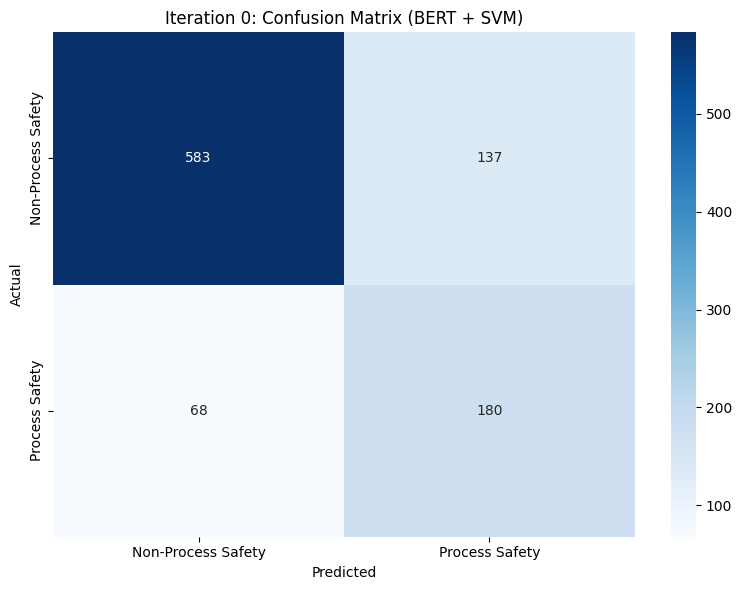

In [25]:
# =============================================================================
# Confusion Matrix Analysis
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(f"\n{'':20} Predicted")
print(f"{'':20} Non-PS    PS")
print(f"Actual Non-PS      {tn:5d}   {fp:5d}")
print(f"Actual PS          {fn:5d}   {tp:5d}")

print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Error rates
fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
print(f"\nFalse Positive Rate: {100*fpr:.2f}%")
print(f"False Negative Rate: {100*fnr:.2f}%")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Process Safety', 'Process Safety'],
    yticklabels=['Non-Process Safety', 'Process Safety']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Iteration 0: Confusion Matrix (BERT + SVM)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

In [26]:
# =============================================================================
# Summary and Gap Analysis
# =============================================================================

import json

# RQ1 Target
RQ1_TARGET = 0.81

# Summary
summary = {
    'iteration': 0,
    'model': 'BERT-base-uncased + Linear SVM',
    'dataset': {
        'total_english_samples': len(english_dataset_minimal),
        'train_samples': len(y_train),
        'test_samples': len(y_test),
        'positive_class_ratio': float(y.mean())
    },
    'results': {
        'accuracy': float(accuracy),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'precision_ps': float(tp / (tp + fp)),
        'recall_ps': float(tp / (tp + fn)),
        'precision_non_ps': float(tn / (tn + fn)),
        'recall_non_ps': float(tn / (tn + fp))
    },
    'confusion_matrix': {
        'tn': int(tn), 'fp': int(fp), 
        'fn': int(fn), 'tp': int(tp)
    },
    'gap_analysis': {
        'current_macro_f1': float(macro_f1),
        'rq1_target': RQ1_TARGET,
        'gap': float(RQ1_TARGET - macro_f1)
    }
}

# Save summary
with open(OUTPUT_DIR / 'iteration_0_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Print summary
print("=" * 60)
print("ITERATION 0 SUMMARY")
print("=" * 60)
print(f"\nModel: {summary['model']}")
print(f"Dataset: {summary['dataset']['total_english_samples']} English samples")
print(f"\nResults:")
print(f"  Accuracy: {summary['results']['accuracy']:.4f}")
print(f"  Macro F1: {summary['results']['macro_f1']:.4f}")
print(f"  Weighted F1: {summary['results']['weighted_f1']:.4f}")
print(f"\nGap Analysis (RQ1):")
print(f"  Current Macro F1: {macro_f1:.4f}")
print(f"  RQ1 Target: >= {RQ1_TARGET}")
print(f"  Gap to close: {RQ1_TARGET - macro_f1:+.4f}")

if macro_f1 >= RQ1_TARGET:
    print("\n✓ RQ1 TARGET ACHIEVED!")
else:
    print(f"\n→ Need to improve Macro F1 by {100*(RQ1_TARGET - macro_f1):.2f} percentage points")

print(f"\nResults saved to: {OUTPUT_DIR}")

ITERATION 0 SUMMARY

Model: BERT-base-uncased + Linear SVM
Dataset: 4840 English samples

Results:
  Accuracy: 0.7882
  Macro F1: 0.7438
  Weighted F1: 0.7958

Gap Analysis (RQ1):
  Current Macro F1: 0.7438
  RQ1 Target: >= 0.81
  Gap to close: +0.0662

→ Need to improve Macro F1 by 6.62 percentage points

Results saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0


In [27]:
# =============================================================================
# Diagnostic: Investigate duplicate removal
# =============================================================================

# 1) Check shape of each source dataframe BEFORE merge
print("=" * 60)
print("SOURCE DATAFRAME SHAPES")
print("=" * 60)
print(f"df_ps: {df_ps.shape[0]} rows")
print(f"df_all: {df_all.shape[0]} rows")
print(f"df_nh_obs: {df_nh_obs.shape[0]} rows")
print(f"Total if concatenated: {df_ps.shape[0] + df_all.shape[0] + df_nh_obs.shape[0]} rows")

# 2) Check unique CASENO in each source
print("\n" + "=" * 60)
print("UNIQUE CASENO IN EACH SOURCE")
print("=" * 60)
print(f"df_ps unique CASENO: {df_ps['CASENO'].nunique()}")
print(f"df_all unique CASENO: {df_all['CASENO'].nunique()}")
print(f"df_nh_obs unique CASENO: {df_nh_obs['CASENO'].nunique()}")

# 3) Check overlap between datasets (same CASENO appearing in multiple sources)
print("\n" + "=" * 60)
print("OVERLAP BETWEEN DATASETS")
print("=" * 60)
caseno_ps = set(df_ps['CASENO'].dropna().astype(str))
caseno_all = set(df_all['CASENO'].dropna().astype(str))
caseno_nh = set(df_nh_obs['CASENO'].dropna().astype(str))

print(f"Overlap df_ps & df_all: {len(caseno_ps & caseno_all)}")
print(f"Overlap df_ps & df_nh_obs: {len(caseno_ps & caseno_nh)}")
print(f"Overlap df_all & df_nh_obs: {len(caseno_all & caseno_nh)}")
print(f"In all three: {len(caseno_ps & caseno_all & caseno_nh)}")

# 4) Total unique CASENO across all sources
all_caseno = caseno_ps | caseno_all | caseno_nh
print(f"\nTotal UNIQUE CASENO across all sources: {len(all_caseno)}")

# 5) Check for duplicates WITHIN each source
print("\n" + "=" * 60)
print("DUPLICATES WITHIN EACH SOURCE")
print("=" * 60)
print(f"df_ps duplicates: {df_ps['CASENO'].duplicated().sum()}")
print(f"df_all duplicates: {df_all['CASENO'].duplicated().sum()}")
print(f"df_nh_obs duplicates: {df_nh_obs['CASENO'].duplicated().sum()}")

# 6) Check common_cols - are we losing data due to column filtering?
print("\n" + "=" * 60)
print("COLUMN INTERSECTION CHECK")
print("=" * 60)
print(f"df_ps columns: {len(df_ps.columns)}")
print(f"df_all columns: {len(df_all.columns)}")
print(f"df_nh_obs columns: {len(df_nh_obs.columns)}")
print(f"Common columns: {len(common_cols)}")
print(f"\nColumns in df_ps but NOT in common: {set(df_ps.columns) - common_cols}")
print(f"Columns in df_all but NOT in common: {set(df_all.columns) - common_cols}")
print(f"Columns in df_nh_obs but NOT in common: {set(df_nh_obs.columns) - common_cols}")

# 7) Verify CASENO is in common_cols
print(f"\n'CASENO' in common_cols: {'CASENO' in common_cols}")

SOURCE DATAFRAME SHAPES
df_ps: 14432 rows
df_all: 28323 rows
df_nh_obs: 929063 rows
Total if concatenated: 971818 rows

UNIQUE CASENO IN EACH SOURCE
df_ps unique CASENO: 895
df_all unique CASENO: 23925
df_nh_obs unique CASENO: 30038

OVERLAP BETWEEN DATASETS
Overlap df_ps & df_all: 564
Overlap df_ps & df_nh_obs: 72
Overlap df_all & df_nh_obs: 22415
In all three: 61

Total UNIQUE CASENO across all sources: 31868

DUPLICATES WITHIN EACH SOURCE
df_ps duplicates: 13537
df_all duplicates: 4398
df_nh_obs duplicates: 899025

COLUMN INTERSECTION CHECK
df_ps columns: 36
df_all columns: 36
df_nh_obs columns: 36
Common columns: 35

Columns in df_ps but NOT in common: {'CASE_OCCURENCE_DATE'}
Columns in df_all but NOT in common: {'CASE_OCCURENCE_DATE'}
Columns in df_nh_obs but NOT in common: {'DATETIME'}

'CASENO' in common_cols: True
